In [ ]:
# load and detect pretrained model(80 classes)

In [1]:
%ls


sample_data/


In [2]:
!git clone https://github.com/WongKinYiu/yolov7.git

Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 34.85 MiB/s, done.
Resolving deltas: 100% (511/511), done.


In [3]:
%cd /content/yolov7

/content/yolov7


In [4]:
%ls

cfg/       export.py   LICENSE.md  requirements.txt  train_aux.py
data/      figure/     models/     scripts/          train.py
deploy/    hubconf.py  paper/      test.py           utils/
detect.py  inference/  README.md   tools/


In [5]:
!wget https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt

--2026-04-12 09:09:58--  https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/511187726/b0243edf-9fb0-4337-95e1-42555f1b37cf?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-12T10%3A07%3A24Z&rscd=attachment%3B+filename%3Dyolov7.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-12T09%3A06%3A34Z&ske=2026-04-12T10%3A07%3A24Z&sks=b&skv=2018-11-09&sig=9etiDTwiMRGb3VN8iDEw8XaZRZlpcPyzURVFegpCBR0%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NTk4Njc5OSwibmJmIjoxNzc1OTg0OTk5LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2luZG

In [ ]:
# Inference Image
!python detect.py --weights yolov7.pt --conf 0.25 --img-size 640 --source "/content/yolov7/Bike (4).jpeg"

Namespace(weights=['yolov7.pt'], source='/content/yolov7/Bike (4).jpeg', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cpu CPU

Traceback (most recent call last):
  File "/content/yolov7/detect.py", line 196, in <module>
    detect()
  File "/content/yolov7/detect.py", line 34, in detect
    model = attempt_load(weights, map_location=device)  # load FP32 model
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov7/models/experimental.py", line 252, in attempt_load
    ckpt = torch.load(w, map_location=map_location)  # load
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1548, in load
    raise pickle.UnpicklingError(_get_wo_message(str(e))) f

In [6]:
!ls /content/yolov7/

cfg	   export.py   LICENSE.md  requirements.txt  train_aux.py
data	   figure      models	   scripts	     train.py
deploy	   hubconf.py  paper	   test.py	     utils
detect.py  inference   README.md   tools	     yolov7.pt


In [7]:
!unzip '/content/yolov7/data.zip' -d '/content/yolov7/data'

Archive:  /content/yolov7/data.zip
   creating: /content/yolov7/data/data/
   creating: /content/yolov7/data/data/test/
   creating: /content/yolov7/data/data/test/images/
  inflating: /content/yolov7/data/data/test/images/img_1008.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1010.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1044.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1046.jpg  
  inflating: /content/yolov7/data/data/test/images/img_105.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1062.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1066.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1097.jpg  
  inflating: /content/yolov7/data/data/test/images/img_11.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1104.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1112.jpg  
  inflating: /content/yolov7/data/data/test/images/img_1126.jpg  
  inflating: /content/yolov7/data/data/

In [8]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [9]:
import os

LABEL_DIR = "/content/yolov7/data/data/train/labels"  # change if needed
MAX_CLASSES = 7  # nc = 7 → valid IDs: 0 to 6

wrong_files = []
total_files = 0

for file in os.listdir(LABEL_DIR):
    if file.endswith(".txt"):
        total_files += 1
        file_path = os.path.join(LABEL_DIR, file)

        with open(file_path, "r") as f:
            for line_no, line in enumerate(f, start=1):
                parts = line.strip().split()

                if len(parts) != 5:
                    print(f"⚠️ Format issue in {file} (line {line_no}) → {line}")
                    wrong_files.append(file)
                    continue

                try:
                    class_id = int(parts[0])

                    if class_id >= MAX_CLASSES or class_id < 0:
                        print(f"❌ Invalid class ID in {file} (line {line_no}) → {class_id}")
                        wrong_files.append(file)

                except:
                    print(f"⚠️ Non-integer class ID in {file} → {line}")
                    wrong_files.append(file)

print("\n======================")
print(f"Total files checked: {total_files}")
print(f"Files with issues: {len(set(wrong_files))}")


Total files checked: 1044
Files with issues: 0


In [11]:
!python train.py --workers 2 --device 0 --batch-size 5 --data data/custom_data.yaml --img 640 640 --cfg cfg/training/yolov7.yaml --weights '/content/yolov7/yolov7.pt' --name yolov7 --hyp data/hyp.scratch.p5.yaml --epochs 45

2026-04-12 09:16:55.228583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775985415.249450    3675 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775985415.256123    3675 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775985415.273861    3675 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775985415.273912    3675 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775985415.273917    3675 computation_placer.cc:177] computation placer alr

In [12]:
from google.colab import files
files.download('/content/yolov7/runs/train/yolov7/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
cd /content/yolov7

/content/yolov7


In [19]:
!ls /content/yolov7/runs/train/yolov7/weights

best.pt       epoch_024.pt  epoch_041.pt  epoch_043.pt	init.pt
epoch_000.pt  epoch_040.pt  epoch_042.pt  epoch_044.pt	last.pt


In [21]:
!python detect.py \
--weights /content/yolov7/runs/train/yolov7/weights/best.pt \
--source /content/yolov7/data/data/test/images \
--conf 0.4

Namespace(weights=['/content/yolov7/runs/train/yolov7/weights/best.pt'], source='/content/yolov7/data/data/test/images', img_size=640, conf_thres=0.4, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 14912.6875MB)

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse
Model Summary: 314 layers, 36514136 parameters, 6194944 gradients
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # 

In [22]:
!zip -r results.zip /content/yolov7/runs/detect/exp5

  adding: content/yolov7/runs/detect/exp5/ (stored 0%)
  adding: content/yolov7/runs/detect/exp5/img_83.jpg (deflated 1%)
  adding: content/yolov7/runs/detect/exp5/img_585.jpg (deflated 6%)
  adding: content/yolov7/runs/detect/exp5/img_280.jpg (deflated 10%)
  adding: content/yolov7/runs/detect/exp5/img_754.jpg (deflated 19%)
  adding: content/yolov7/runs/detect/exp5/img_567.jpg (deflated 6%)
  adding: content/yolov7/runs/detect/exp5/img_328.jpg (deflated 6%)
  adding: content/yolov7/runs/detect/exp5/img_1062.jpg (deflated 6%)
  adding: content/yolov7/runs/detect/exp5/img_599.jpg (deflated 2%)
  adding: content/yolov7/runs/detect/exp5/img_1478.jpg (deflated 5%)
  adding: content/yolov7/runs/detect/exp5/img_468.jpg (deflated 2%)
  adding: content/yolov7/runs/detect/exp5/img_625.jpg (deflated 6%)
  adding: content/yolov7/runs/detect/exp5/img_37.jpg (deflated 10%)
  adding: content/yolov7/runs/detect/exp5/img_212.jpg (deflated 6%)
  adding: content/yolov7/runs/detect/exp5/img_1223.jpg (de

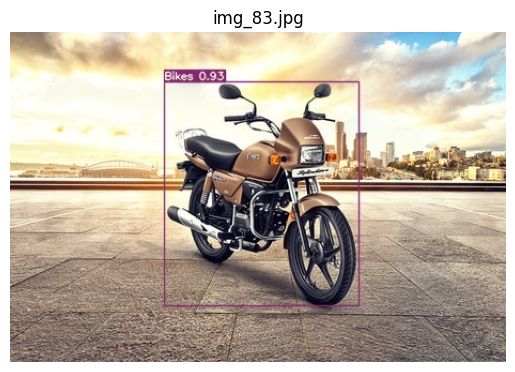

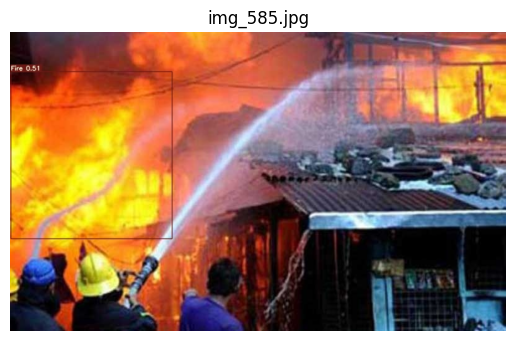

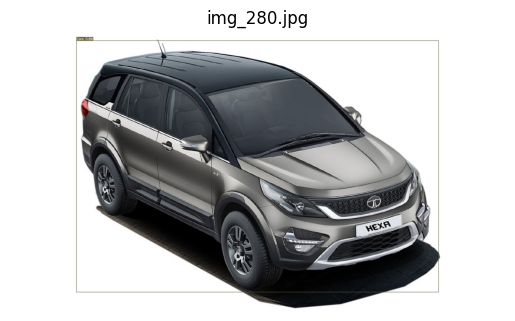

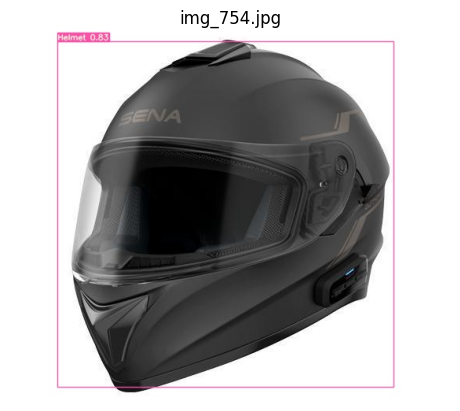

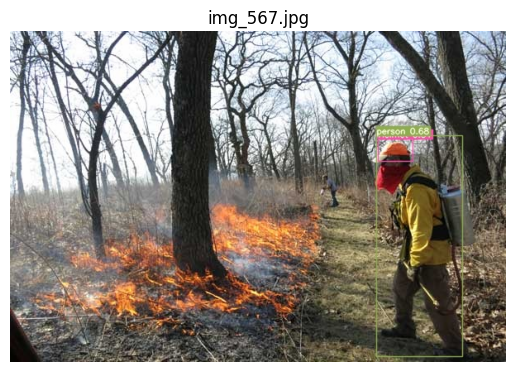

In [24]:
import matplotlib.pyplot as plt
import cv2
import os

folder = "/content/yolov7/runs/detect/exp5"

for img_name in os.listdir(folder)[:5]:  # show first 5 images
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [ ]:
!zip -r results.zip /content/yolov7/runs/detect/exp5

In [23]:
from google.colab import files
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>